# 4.2 - Mecanismos de atención

En este notebook, exploraremos cómo resolver un problema de predicción de palabras utilizando mecanismos de self-attention en lugar de LSTMs.

El mecanismo de self-attention permite que cada elemento de una secuencia preste atención a otros elementos de la misma secuencia. Esto es útil para capturar dependencias a **largo plazo** a diferencia de las redes recurrentes tradicionales.

Además, a diferencia de las redes LSTM o GRU, estas son **altamente paralelizables** dado que permiten tratar cada elemento de la secuencia de forma individual.


## Conjunto de datos

Utilizaremos el mismo conjunto de datos que en la práctica anterior: el libro "Trafalgar" de Benito Pérez Galdós. Nuestro objetivo será predecir la siguiente palabra en una secuencia de 5 palabras dadas.

### Descargar conjunto

In [4]:
!pip install unidecode -q
import requests

# Descargar el texto de "Trafalgar" de Benito Pérez Galdós
url = "https://www.gutenberg.org/cache/epub/16961/pg16961.txt"
response = requests.get(url, timeout=30)
text = response.text

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 16.2 MB/s eta 0:00:00


### Preprocesar texto

Normalmente los conjuntos de datos contienen errores o elementos no deseados, en esta parte los eliminaremos. Algunos ejemplos típicos son los números, los saltos de línea `\n` o los tabuladores `\t`. <br>
Si abres la url del libro en tu navegador verás que al inicio y al final nos aparece un aviso de copyright que tendremos que eliminar.

En este punto verás que también separamos el texto en frases haciendo uso de la librería de texto `nltk`.

In [5]:
import re
import time
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.tokenize import sent_tokenize
from unidecode import unidecode

# Eliminar saltos de línea y retornos de carro
text = re.sub(r'[\n\r]+', ' ', text)
# Eliminamos cabecera y fin en inglés
text = text.split("FIN DE TRAFALGAR")[0]
text = text.split(" -I- ")[1]
# Dividir el texto en frases utilizando la librería nltk
sentences = sent_tokenize(text)
# Eliminar acentos utilizando la librería unidecode
sentences = [unidecode(s) for s in sentences]
# Pasar a minúsculas y eliminar resto de caracteres extraños (dos puntos, punto y coma, números...)
sentences = [re.sub(r'[^a-z\s]', '', s.lower()) for s in sentences]

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


### Obtener vocabulario

Una vez tenemos todas las frases, para codificar cada una de las palabras del texto es necesario obtener el llamado `corpus` o `vocabulario`. Este nos sirve para saber que palabras únicas (sin repetición) aparecen en nuestro texto, lo cual es útil para asignar un índice a cada una. Como verás, en este caso asignamos el índice en función de la frecuencia de aparición, por tanto, la palabra más frecuente tendrá el índice más bajo.

Como recordarás, nuestro objetivo es que, dado un texto de máximo 5 palabras, el modelo entrenado sea capaz de continuar la frase hasta que decida finalizarla. Para lograrlo tenemos que tener en cuenta varios escenarios:
* ¿Y si nos dan menos de 5 palabras?
* ¿Como hacemos para detectar que la palabra generada por el modelo es la última de la frase?

Para solventar estos problemas, vamos a añadir dos palabras nuevas o `tokens` nuevos a nuestro vocabulario:
* **\<pad\>**: Token que representa *padding*, es decir, si nos dan menos de 5 palabras, rellenaremos las que falten con este padding.
* **\<eos\>**: Token que representa *end-of-sequence*, es decir, fin de secuencia. Si el modelo predice este token, sabremos que ya se acabó la frase y podemos detener la generación.


In [6]:
from collections import Counter

# Crear una lista con todas las palabras del texto
words = " ".join(sentences).split()
# Obtener el corpus del texto (todas las palabras que aparecen y su frecuencia)
word_counts = Counter(words)
# Filtrar palabras que aparecen menos de 5 veces, dado que no aportan mucho
word_counts = {word: count for word, count in word_counts.items() if count >=5}
# Ordenamos el corpus por frecuencia
word_counts = dict(sorted(word_counts.items(), key=lambda x: x[1], reverse=True))
# Extraemos solo las claves del diccionario anterior para crear el corpus
vocab = list(word_counts.keys())
# Añadimos tokens especiales <pad> (padding), <eos> (end of sequence), y <unk> (unknown)
vocab = ["<pad>", "<unk>"] + vocab + ["<eos>"]
# Generamos un diccionario (y su inverso) donde asignamos un id a cada palabra según su frecuencia.
# La palabra más frecuente será la 1. El 0 lo dejamos para el padding
word_to_ix = {word: i for i, word in enumerate(vocab)}
ix_to_word = {i: word for i, word in enumerate(vocab)}
vocab_size = len(vocab)

print(f'Tamaño del vocabulario: {vocab_size}')
print(f'Word to Index mapping: {word_to_ix}')

Tamaño del vocabulario: 1219
Word to Index mapping: {'<pad>': 0, '<unk>': 1, 'de': 2, 'que': 3, 'la': 4, 'y': 5, 'el': 6, 'a': 7, 'en': 8, 'no': 9, 'los': 10, 'se': 11, 'con': 12, 'mi': 13, 'por': 14, 'me': 15, 'un': 16, 'su': 17, 'del': 18, 'las': 19, 'al': 20, 'como': 21, 'para': 22, 'mas': 23, 'lo': 24, 'una': 25, 'si': 26, 'yo': 27, 'era': 28, 'pero': 29, 'le': 30, 'habia': 31, 'es': 32, 'nos': 33, 'sus': 34, 'cuando': 35, 'tan': 36, 'sin': 37, 'todos': 38, 'o': 39, 'pues': 40, 'ni': 41, 'aquel': 42, 'muy': 43, 'amo': 44, 'todo': 45, 'esta': 46, 'despues': 47, 'mis': 48, 'ya': 49, 'd': 50, 'porque': 51, 'fue': 52, 'tambien': 53, 'ha': 54, 'este': 55, 'marcial': 56, 'aquella': 57, 'estaba': 58, 'navio': 59, 'escuadra': 60, 'sobre': 61, 'dos': 62, 'esto': 63, 'ingleses': 64, 'bien': 65, 'hasta': 66, 'mismo': 67, 'gran': 68, 'entonces': 69, 'desde': 70, 'les': 71, 'dona': 72, 'dios': 73, 'tenia': 74, 'donde': 75, 'nuestra': 76, 'cadiz': 77, 'san': 78, 'usted': 79, 'cual': 80, 'poco': 

### Análisis de datos
En todos los problemas de aprendizaje, es muy importante hacer un análisis de los datos con los que vamos a trabajar, lo cual nos puede servir para diagnosticar o evitar futuros problemas.<br>
En este caso realizamos un simple análisis de la frecuencia de las palabras.

Como siempre suele suceder en estos casos, las palabras más comunes son las llamadas `stop-words`. Estas palabras son las que más solemos repetir en nuestros textos y las forman los artículos, las preposiciones, las conjunciones, ...

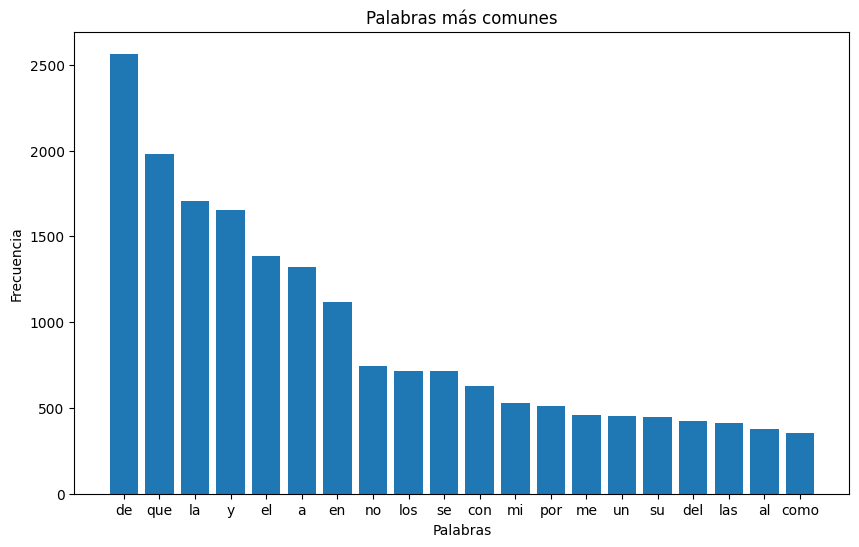

In [7]:
import matplotlib.pyplot as plt

# Visualización de las 20 palabras más comunes
words_x = list(word_counts.keys())[:20]
counts_y = list(word_counts.values())[:20]

plt.figure(figsize=(10, 6))
plt.bar(words_x, counts_y)
plt.title('Palabras más comunes')
plt.xlabel('Palabras')
plt.ylabel('Frecuencia')
plt.show()

### Crear dataset Pytorch
Una vez tenemos nuestro conjunto limpio y analizado, podemos crear los ejemplos con los que alimentaremos nuestro modelo. Como habíamos comentado queremos intentar completar una frase dadas, como máximo 5 palabras.<br>
En la siguiente clase `SentenceDataset` crearemos los ejemplos a partir de las frases del texto descargado. Estos ejemplos han de reflejar todos los escenarios a los que luego queremos que nuestro modelo pueda enfrentarse.

Por tanto, para cada frase, nuestro `Dataset` creará los siguientes ejemplos:
* Frase: *Frase de ejemplo*
    * [\<pad\>, \<pad\>, \<pad\>, \<pad\>, frase], de
    * [\<pad\>, \<pad\>, \<pad\>,  frase, de], ejemplo
    * [\<pad\>, \<pad\>, frase,  de, ejemplo], \<eos\>

El primer vector es la secuencia de entrada y el elemento del final es la salida deseada. Ten en cuenta que al modelo no le damos el texto, le daremos los índices de cada palabra.


Si nuestro `word_to_ix` fuese este:
```python
word_to_ix = {"<pad>":0, "frase":1, "de":2, "ejemplo":3, "<eos>":4}
```
Nuestros ejemplos quedarían así:
* [0, 0, 0, 0, 1], 2
* [0, 0, 0, 1, 2], 3
* [0, 0, 1, 2, 3], 4

> **Nota:** La attention soporta la entrada de máscaras que sirven para indicar que elementos de la entrada son irrelevantes (\<pad\>). Se ha modificado el método `__get_item__` para que, además de la x y la y, también retorne un vector con la máscara de cada ejemplo.

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

class SentenceDataset(Dataset):
    def __init__(self, sentences, word_to_ix, seq_length):
        self.data = []
        self.seq_length = seq_length
        self.word_to_ix = word_to_ix

        # El índice para <unk>
        unk_index = self.word_to_ix["<unk>"]

        # Para cada frase del conjunto de datos..
        for sentence in sentences:
            # Separamos la frase en una lista de palabras y al final se añadimos el token <eos>
            words = sentence.split() + ['<eos>']
            # Para cada palabra, creamos un ejemplo
            for i in range(len(words)-1):
                # Obtenemos las palabras de cada ejemplo
                seq_in = words[max(0, i+1 - seq_length):i+1]
                # Añadir padding si es necesario
                seq_in = ['<pad>'] * (seq_length - len(seq_in)) + seq_in
                # Obtenemos la salida deseada para la secuencia de entrada (la siguiente palabra)
                seq_out = words[i+1]
                # Convertir palabras a índices
                seq_in_indices = [self.word_to_ix.get(word, unk_index) for word in seq_in]
                seq_out_index = self.word_to_ix.get(seq_out, unk_index)

                # Almacenamos el ejemplo solo si seq_out no es <unk>
                if seq_out_index != unk_index:
                    self.data.append((torch.tensor(seq_in_indices, dtype=torch.long), torch.tensor(seq_out_index, dtype=torch.long)))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Obtenemos un ejemplo concreto (ya se han creado todos en el init)
        seq_in, seq_out = self.data[idx]
        # Crear la máscara de padding (Las posiciones de padding se marcan como True)
        mask = seq_in == self.word_to_ix["<pad>"]
        return seq_in, seq_out, mask

seq_length = 5
dataset = SentenceDataset(sentences, word_to_ix, seq_length)
print(len(dataset))

40595


### Dividir el conjunto de datos
Dividimos el conjunto al completo en ``entrenamiento``, ``validación`` y ``test`` (80%,10%,10%) de forma aleatoria.

In [9]:
# Fijar la semilla para obtener reproducibilidad
seed = 42
torch.manual_seed(seed)  # Semilla para PyTorch

# Dividir el dataset en entrenamiento, validación y prueba
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

batch_size = 256

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## 4.2.3. - Modelo
Para este problema crearemos el modelo más sencillo posible:
* **Capa Embedding**: Para cada elemento de la entrada, aprenderá un embedding que lo representará en un espacio de dimensión `embed_size`.
* **Capa MultiheadAttention**: Esta capa permite al modelo enfocarse en diferentes partes de la secuencia de entrada simultáneamente. Cada "cabeza" en la atención múltiple (multi-head) puede capturar distintos patrones de relación entre los elementos de la secuencia.
    * En la capa LSTM de la práctica anterior, el último elemento de la secuencia de salida contiene información de toda la secuencia, **en este caso no**.
    * El número de heads se configura mediante `num_heads`.
* **Capa Linear**: Proyecta el vector del último elemento de la salida de la LSTM en un espacio de tamaño `output_size`. En este caso `output_size` es igual al tamaño del vocabulario dado que estamos intentando resolver un problema de multi-clasificación.

Nótese que no aplicamos la función `softmax` dado que esta se aplica internamente en la `CrossEntropyLoss`.

In [10]:
import torch
import torch.nn as nn

class SelfAttentionModel(nn.Module):
    def __init__(self, vocab_size, embed_size, num_heads, seq_length):
        super(SelfAttentionModel, self).__init__()
        # Capa de embedding: Convierte los índices de las palabras en vectores densos de tamaño embed_size
        self.embedding = nn.Embedding(vocab_size, embed_size)
        # Capa de atención múltiple (MultiheadAttention): Permite al modelo enfocarse en diferentes partes de la secuencia
        self.attention = nn.MultiheadAttention(embed_size, num_heads, batch_first=True)
        # Capa de flatten para aplanar la salida de la atención
        self.flatten = nn.Flatten()
        # Capa lineal para proyección al espacio de salida
        self.fc = nn.Linear(embed_size * seq_length, vocab_size)

    def forward(self, sentence, mask=None, return_att_mtx=False):
        # Aplicación de la capa de embedding para convertir las palabras en embeddings
        embeds = self.embedding(sentence)
        # Aplicamos la atención sobre la secuencia de embeddings (en este caso query, key y value son los mismos)
        # La máscara se aplica a la capa de atención para controlar qué posiciones se deben ignorar (las <pad>)
        attention_out, attention_weights = self.attention(embeds, embeds, embeds, key_padding_mask=mask)
        # Aplanar la salida de la atención
        flattened_out = self.flatten(attention_out)
        # Proyectar al espacio de salida
        out = self.fc(flattened_out)

        if return_att_mtx:
            return out, attention_weights
        else:
            return out

In [11]:
# Hiperparámetros del modelo
embed_size = 8
num_heads = 1
num_epochs = 25
learning_rate = 0.005

# Inicializar los modelos, loss function y optimizer
model = SelfAttentionModel(vocab_size, embed_size, num_heads, seq_length)
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

## 4.2.4. - Entrenamiento

In [12]:
# Función para calcular la precisión (accuracy) en un conjunto de datos
def calculate_accuracy(model, data_loader, K=1):
    model.eval()  # Configuramos el modelo en modo evaluación (no se actualizan los pesos)
    correct = 0  # Contador para predicciones correctas
    total = 0  # Contador para el número total de ejemplos

    with torch.no_grad():  # Desactivamos el cálculo de gradientes
        for inputs, targets, masks in data_loader:
            inputs, targets, masks = inputs.to(device), targets.to(device), masks.to(device)
            outputs = model(inputs, masks)  # Hacemos una predicción con el modelo
            # Obtenemos las probabilidades de las clases (Top-K)
            topk = outputs.topk(K, dim=1)[1]
            # Creamos una máscara que indica si la etiqueta correcta está entre las top-K predicciones
            correct_mask = topk.eq(targets.view(-1, 1).expand_as(topk))
            correct += correct_mask.sum().item()  # Contamos las predicciones correctas
            total += targets.size(0)  # Contamos el número total de ejemplos

    accuracy = correct / total  # Calculamos la precisión como el porcentaje de predicciones correctas
    return accuracy

# Función de entrenamiento y validación
def train_model(model, optimizer, train_loader, val_loader, num_epochs):
    model.train()  # Configuramos el modelo en modo entrenamiento
    for epoch in range(num_epochs):
        start_time = time.time()  # Registramos el tiempo de inicio de la epoch

        total_train_loss = 0  # Inicializamos la variable para acumular la pérdida de entrenamiento
        total_val_loss = 0    # Inicializamos la variable para acumular la pérdida de validación

        # Entrenamiento
        model.train() # Configuramos el modelo en modo entrenamiento
        for inputs, targets, masks in train_loader:  # Iteramos sobre los datos de entrenamiento
            inputs, targets, masks = inputs.to(device), targets.to(device), masks.to(device)
            optimizer.zero_grad()  # Reseteamos los gradientes del optimizador
            outputs = model(inputs, masks)  # Hacemos una predicción con el modelo
            loss = criterion(outputs, targets)  # Calculamos la pérdida entre la predicción y el objetivo
            loss.backward()  # Calculamos los gradientes (backpropagation)
            optimizer.step()  # Actualizamos los pesos del modelo según el optimizador
            total_train_loss += loss.item()  # Acumulamos la pérdida de esta iteración

        # Calculamos la precisión para el conjunto de entrenamiento
        train_accuracy = calculate_accuracy(model, train_loader)

        # Validación
        model.eval()  # Configuramos el modelo en modo evaluación (no se actualizan los pesos)
        with torch.no_grad():  # Desactivamos el cálculo de gradientes para ahorrar memoria y mejorar la velocidad
            for inputs, targets, masks in val_loader:  # Iteramos sobre los datos de validación
                inputs, targets, masks = inputs.to(device), targets.to(device), masks.to(device)
                outputs = model(inputs, masks)  # Hacemos una predicción con el modelo
                loss = criterion(outputs, targets)  # Calculamos la pérdida para validación
                total_val_loss += loss.item()  # Acumulamos la pérdida de esta iteración

        # Calculamos la precisión para el conjunto de validación
        val_accuracy = calculate_accuracy(model, val_loader)
        val_accuracy_3 = calculate_accuracy(model, val_loader, K=3)

        # Calculamos el tiempo total de la epoch
        epoch_time = time.time() - start_time

        # Imprimimos las estadísticas de la epoch: pérdida de entrenamiento, validación, precisión y tiempo
        print(f'Epoch [{epoch+1}/{num_epochs}], '
              f'Train Loss: {total_train_loss/len(train_loader):.4f}, '
              f'Val Loss: {total_val_loss/len(val_loader):.4f}, '
              f'Train T1 Accuracy: {train_accuracy:.4f}, '
              f'Val T1 Accuracy: {val_accuracy:.4f}, '
              f'Val T3 Accuracy: {val_accuracy_3:.4f}, '
              f'Time: {epoch_time:.2f} sec')

# Entrenar el modelo Attention
print(f"Entrenando modelo Attention en {device}...")
train_model(model, optimizer, train_loader, val_loader, num_epochs)

Entrenando modelo Attention en cpu...
Epoch [1/25], Train Loss: 5.7099, Val Loss: 5.4596, Train T1 Accuracy: 0.0641, Val T1 Accuracy: 0.0594, Val T3 Accuracy: 0.1520, Time: 2.47 sec
Epoch [2/25], Train Loss: 5.3386, Val Loss: 5.3549, Train T1 Accuracy: 0.0789, Val T1 Accuracy: 0.0766, Val T3 Accuracy: 0.1668, Time: 2.87 sec
Epoch [3/25], Train Loss: 5.1820, Val Loss: 5.2655, Train T1 Accuracy: 0.0891, Val T1 Accuracy: 0.0833, Val T3 Accuracy: 0.1838, Time: 1.32 sec
Epoch [4/25], Train Loss: 5.0209, Val Loss: 5.2097, Train T1 Accuracy: 0.0978, Val T1 Accuracy: 0.0875, Val T3 Accuracy: 0.2040, Time: 1.32 sec
Epoch [5/25], Train Loss: 4.8791, Val Loss: 5.1901, Train T1 Accuracy: 0.1037, Val T1 Accuracy: 0.0924, Val T3 Accuracy: 0.2102, Time: 1.32 sec
Epoch [6/25], Train Loss: 4.7599, Val Loss: 5.1861, Train T1 Accuracy: 0.1103, Val T1 Accuracy: 0.0983, Val T3 Accuracy: 0.2104, Time: 1.27 sec
Epoch [7/25], Train Loss: 4.6568, Val Loss: 5.1938, Train T1 Accuracy: 0.1171, Val T1 Accuracy: 0.

## 4.2.5. - Prueba

In [13]:
def predict(model, text, word_to_ix, ix_to_word, seq_length, max_len=20):
    # Asegurarse de que el modelo esté en modo de evaluación
    model.eval()

    # Preprocesar el texto de entrada
    text = unidecode(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()

    # Convertir palabras a índices
    input_sequence = [word_to_ix.get(word, word_to_ix['<pad>']) for word in words]
    input_sequence = input_sequence[-seq_length:]  # Tomar solo las últimas seq_length palabras
    input_sequence = [0] * (seq_length - len(input_sequence)) + input_sequence

    # Convertir la secuencia a tensor
    input_tensor = torch.tensor([input_sequence], dtype=torch.long)

    # Inicializar la lista de palabras generadas
    generated_words = words
    predicted_word = ""

    with torch.no_grad():
        while len(generated_words)<=max_len and predicted_word!='<eos>':
            input_tensor = input_tensor.to(device)
            mask = input_tensor == word_to_ix['<pad>']
            # Hacer una predicción usando el modelo
            output = model(input_tensor, mask)

            # Obtener la palabra con la probabilidad más alta
            _, predicted_index = torch.max(output, 1)
            predicted_word = ix_to_word[predicted_index.item()]

            # Añadir la palabra generada a la lista
            generated_words.append(predicted_word)

            # Actualizar la secuencia de entrada para la siguiente predicción
            input_sequence = input_sequence[1:] + [predicted_index.item()]
            input_tensor = torch.tensor([input_sequence], dtype=torch.long)

    return ' '.join(generated_words)

# Ejemplo de texto de entrada
input_text = "La batalla de"
predicted_text = predict(model, input_text, word_to_ix, ix_to_word, seq_length)
print(predicted_text)

la batalla de la escuadra combinada me hallaba de la puerta y que me estaba de la caleta pedazo de la


## 4.2.6. - Ejercicios

> **EJERCICIO:** ¿Que sucede si no se eliminan los ejemplos que predicen \<unk\> del dataset?


### Consecuencias de no eliminar el token `<unk>`

Si mantienes los ejemplos que contienen o predicen el token **`<unk>`** (Unknown), el rendimiento y comportamiento de tu Transformer se degradará debido a tres factores críticos:

1. **Sesgo hacia la "Ignorancia" (Predicción Vaga):**
   El token `<unk>` agrupa a todas las palabras fuera del vocabulario. Al ser estadísticamente muy frecuente, el modelo descubrirá que predecir `<unk>` es una apuesta segura para minimizar la función de pérdida (`CrossEntropyLoss`). En lugar de aprender a generar palabras reales, el modelo tenderá a responder con `<unk>` de forma sistemática.

2. **Ruido en el Mecanismo de Atención:**
   Tus modelos (`SelfAttentionModel` y `ProportionalAttentionModel`) calculan la relación semántica entre palabras. Si la secuencia tiene múltiples tokens `<unk>`, el modelo intentará buscar correlaciones sobre vectores que representan conceptos totalmente dispares (por ejemplo, "microchip" y "filosofía" se mapearán al mismo espacio si ambos son desconocidos). Esto destruye la estructura sintáctica que las capas de atención intentan aprender.

3. **Métricas de Precisión Artificiales (Métricas Infladas):**
   Tu función `calculate_accuracy` evalúa como "correcto" cualquier acierto posicional. Si el dataset pide un `<unk>` y el modelo predice `<unk>`, la métrica subirá. Esto genera una **falsa sensación de éxito**: tendrás un *Accuracy* alto en validación, pero el modelo en la práctica estará generando texto sin sentido o bucles infinitos de palabras desconocidas.

---

### Estrategia Recomendada en tu Pipeline

* **Filtrado:** Elimina cualquier secuencia donde el *target* (la palabra a predecir) sea un `<unk>`.
* **Umbral de Texto:** Si una frase de entrada tiene más del 10% de sus palabras mapeadas como `<unk>`, descarta el ejemplo completo del `DataLoader`.

> **EJERCICIO:** Extrae y representa la matriz de atención del modelo para el texto: _El barco es muy antiguo_ .Puedes utilizar el siguiente código para visualizarla:


In [19]:
def plot_att_mtx(att_mtx, text):
    # Este método recibe la matriz de atención y un texto
    words = text.split()
    fig, ax = plt.subplots()
    cax = ax.matshow(att_mtx, cmap='viridis')
    fig.colorbar(cax)

    ax.set_xticks(torch.arange(len(words)))
    ax.set_yticks(torch.arange(len(words)))

    ax.set_xticklabels(words, rotation=90)
    ax.set_yticklabels(words)

    plt.show()

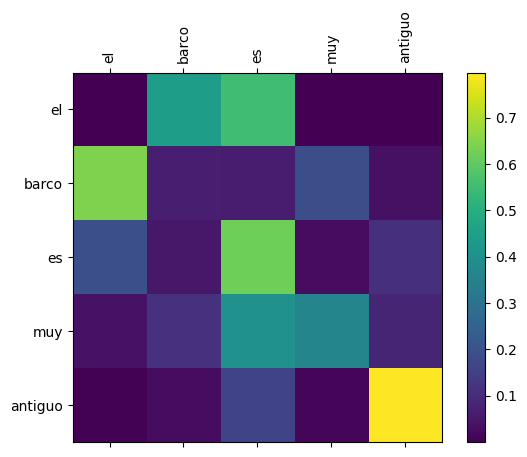

In [20]:
# ==========================================
# 2. RESOLUCIÓN DEL EJERCICIO
# ==========================================

input_text = "El barco es muy antiguo ."

# Replicamos el preprocesamiento exacto de tu función predict
processed_text = unidecode(input_text).lower()
processed_text = re.sub(r'[^a-z\s]', '', processed_text)
words = processed_text.split()
num_words = len(words)

# Convertir palabras a índices con padding (idéntico a tu arquitectura)
input_sequence = [word_to_ix.get(word, word_to_ix['<pad>']) for word in words]
input_sequence = input_sequence[-seq_length:]
input_sequence = [0] * (seq_length - len(input_sequence)) + input_sequence

# Convertir a tensores y enviar al dispositivo
input_tensor = torch.tensor([input_sequence], dtype=torch.long).to(device)
mask = (input_tensor == word_to_ix['<pad>']).to(device)

# Evaluación para extraer los pesos de atención
model.eval()
with torch.no_grad():
    # Forzamos return_att_mtx=True solo para esta extracción
    _, attention_weights = model(input_tensor, mask=mask, return_att_mtx=True)

# Mapeo dimensional:
# El modelo opera en dimensiones fijas (seq_length x seq_length) debido al padding.
# Extraemos el lote [0] y recortamos la esquina inferior derecha (las palabras reales).
matriz_atencion = attention_weights[0, -num_words:, -num_words:].cpu()

# 3. Representación visual
plot_att_mtx(matriz_atencion, processed_text)

> **EJERCICIO:** Crea un nuevo modelo, sin eliminar el existente, donde se aprendan representaciones diferentes para cada palabra: Una para las **queries**, otra para las **keys** y otra para los **values**. Entrena el modelo de nuevo y compáralo con el anterior.

In [22]:
class ProportionalAttentionModel(nn.Module):
    def __init__(self, vocab_size, embed_size, num_heads, seq_length):
        super(ProportionalAttentionModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)

        # NUEVO: Capas lineales para proyectar Query, Key y Value de forma independiente
        self.q_proj = nn.Linear(embed_size, embed_size)
        self.k_proj = nn.Linear(embed_size, embed_size)
        self.v_proj = nn.Linear(embed_size, embed_size)

        self.attention = nn.MultiheadAttention(embed_size, num_heads, batch_first=True)
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(embed_size * seq_length, vocab_size)

    def forward(self, sentence, mask=None, return_att_mtx=False):
        embeds = self.embedding(sentence)

        # NUEVO: Generamos representaciones diferentes aplicando las proyecciones
        queries = self.q_proj(embeds)
        keys = self.k_proj(embeds)
        values = self.v_proj(embeds)

        # Pasamos las proyecciones independientes a la capa de atención
        attention_out, attention_weights = self.attention(
            queries, keys, values,
            key_padding_mask=mask,
            need_weights=True
        )

        flattened_out = self.flatten(attention_out)
        out = self.fc(flattened_out)

        if return_att_mtx:
            return out, attention_weights
        return out

In [23]:
# Inicializar el nuevo modelo QKV con los mismos hiperparámetros
new_model = ProportionalAttentionModel(vocab_size, embed_size, num_heads, seq_length)
new_model.to(device)

# Definir optimizador exclusivo para el nuevo modelo
new_optimizer = optim.Adam(new_model.parameters(), lr=learning_rate)

# Entrenar el nuevo modelo
print(f"Entrenando el nuevo modelo Proportional Attention (QKV) en {device}...")
train_model(new_model, new_optimizer, train_loader, val_loader, num_epochs)

Entrenando el nuevo modelo Proportional Attention (QKV) en cpu...
Epoch [1/25], Train Loss: 5.6660, Val Loss: 5.4912, Train T1 Accuracy: 0.0635, Val T1 Accuracy: 0.0572, Val T3 Accuracy: 0.1412, Time: 1.49 sec
Epoch [2/25], Train Loss: 5.4192, Val Loss: 5.4613, Train T1 Accuracy: 0.0648, Val T1 Accuracy: 0.0576, Val T3 Accuracy: 0.1439, Time: 1.50 sec
Epoch [3/25], Train Loss: 5.3577, Val Loss: 5.3992, Train T1 Accuracy: 0.0787, Val T1 Accuracy: 0.0727, Val T3 Accuracy: 0.1705, Time: 1.64 sec
Epoch [4/25], Train Loss: 5.2026, Val Loss: 5.2902, Train T1 Accuracy: 0.0873, Val T1 Accuracy: 0.0803, Val T3 Accuracy: 0.1927, Time: 1.79 sec
Epoch [5/25], Train Loss: 5.0480, Val Loss: 5.2384, Train T1 Accuracy: 0.0925, Val T1 Accuracy: 0.0833, Val T3 Accuracy: 0.2047, Time: 1.52 sec
Epoch [6/25], Train Loss: 4.9369, Val Loss: 5.2091, Train T1 Accuracy: 0.0991, Val T1 Accuracy: 0.0875, Val T3 Accuracy: 0.2116, Time: 1.48 sec
Epoch [7/25], Train Loss: 4.8406, Val Loss: 5.1955, Train T1 Accuracy:

In [24]:
# Evaluar modelo base anterior
loss_fn = nn.CrossEntropyLoss() # Asegurar criterio estándar

def evaluate_metrics(m, loader, name):
    m.eval()
    t1 = calculate_accuracy(m, loader, K=1)
    t3 = calculate_accuracy(m, loader, K=3)
    print(f"--- {name} ---")
    print(f"Val Top-1 Accuracy: {t1:.4f}")
    print(f"Val Top-3 Accuracy: {t3:.4f}\n")

evaluate_metrics(model, val_loader, "Modelo Anterior (Self-Attention Directo)")
evaluate_metrics(new_model, val_loader, "Modelo Nuevo (Proyecciones QKV Separadas)")

--- Modelo Anterior (Self-Attention Directo) ---
Val Top-1 Accuracy: 0.1017
Val Top-3 Accuracy: 0.2203

--- Modelo Nuevo (Proyecciones QKV Separadas) ---
Val Top-1 Accuracy: 0.0978
Val Top-3 Accuracy: 0.2151

